In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.calibration import calibration_curve

In [3]:
import os

os.makedirs("../visualizations/evaluation", exist_ok=True)

print("Visualization folder ready")

Visualization folder ready


In [4]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

y_test = y_test.values.ravel()

print("Test shape:", X_test.shape)

Test shape: (636, 12)


In [5]:
model = pickle.load(open("../models/best_model.pkl", "rb"))

print("Best model loaded")
print(model)

Best model loaded
RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)


In [ ]:
# Generate predictions and probabilities on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Predictions generated")

Predictions generated


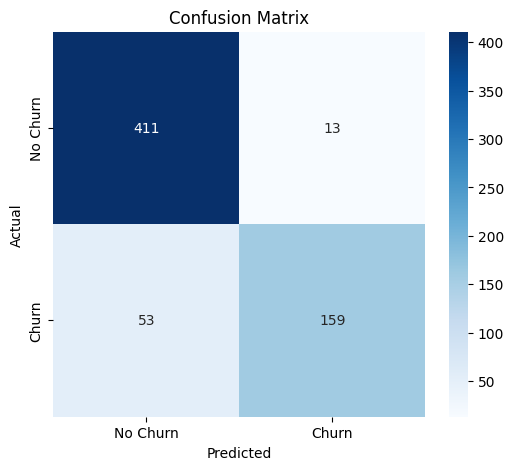

In [ ]:
# Confusion matrix and core metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Confusion matrix:\n", cm)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../visualizations/evaluation/confusion_matrix.png")

plt.show()

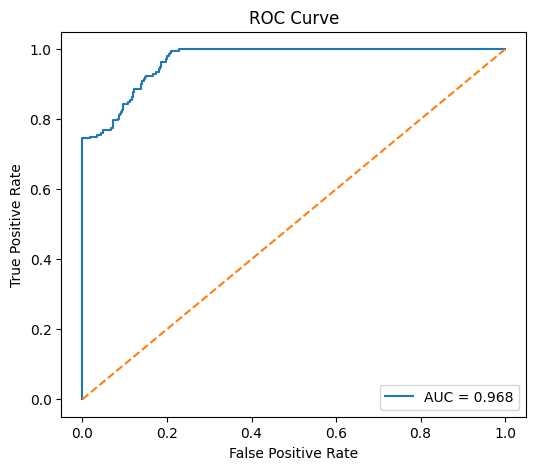

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.savefig("../visualizations/evaluation/roc_curve.png")

plt.show()

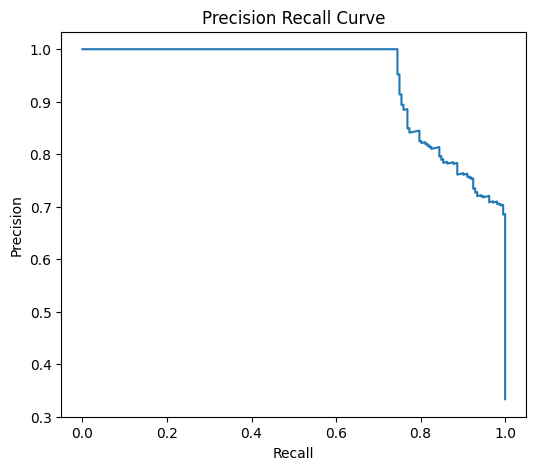

In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.savefig("../visualizations/evaluation/precision_recall_curve.png")

plt.show()

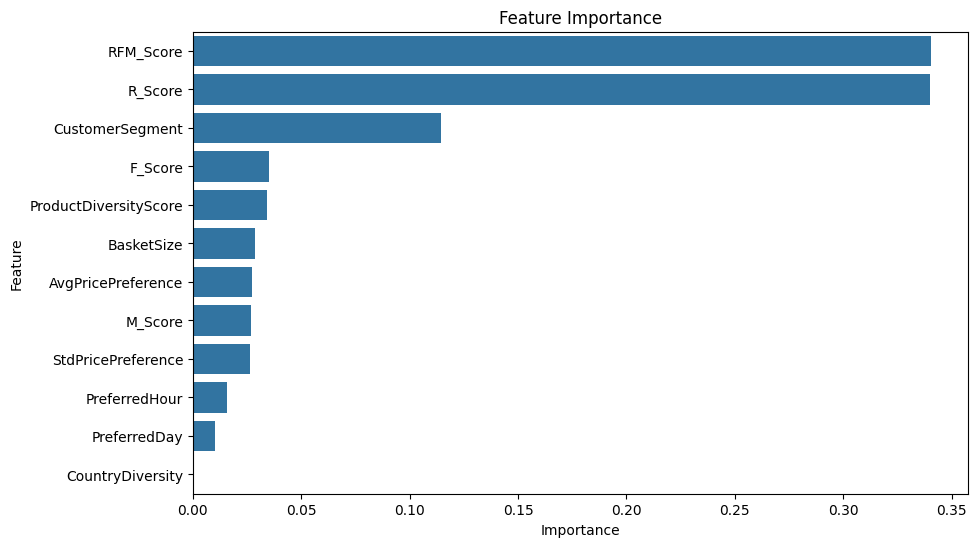

In [ ]:
# Feature importance (works for tree-based models; for Logistic Regression, use coef_ as needed)
feature_names = X_test.columns

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance_df
    )

    plt.title("Feature Importance")

    plt.savefig("../visualizations/evaluation/feature_importance.png")

    plt.show()
else:
    print("Current best model does not expose feature_importances_; skip importance plot.")

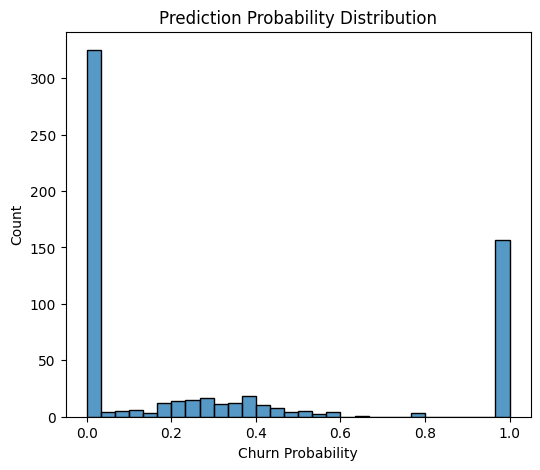

In [ ]:
# Prediction probability distribution
plt.figure(figsize=(6,5))

sns.histplot(y_prob, bins=30)

plt.title("Prediction Probability Distribution")

plt.xlabel("Churn Probability")

plt.savefig("../visualizations/evaluation/prediction_distribution.png")

plt.show()

In [ ]:
# Misclassified customers DataFrame for error analysis
misclassified_df = pd.DataFrame({
    "Predicted": y_pred,
    "Actual": y_test,
    "Churn_Probability": y_prob,
})
misclassified_df = misclassified_df[misclassified_df["Predicted"] != misclassified_df["Actual"]]

print("Number of misclassified customers:", len(misclassified_df))

misclassified_df.head()

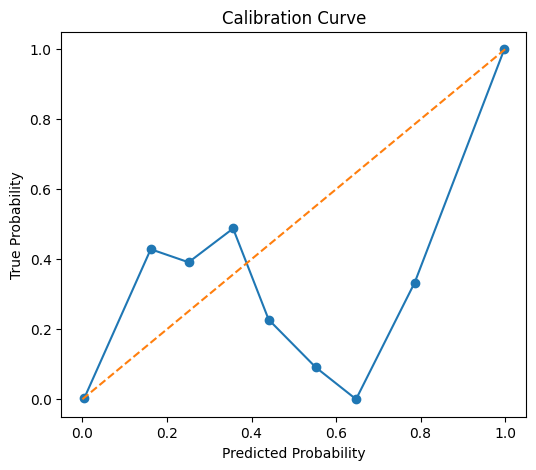

: 

In [ ]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,5))

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")

plt.title("Calibration Curve")

plt.savefig("../visualizations/evaluation/calibration_curve.png")

plt.show()